Reading audio files...
Total Audio Files: 2880
Feature Shape: (2880, 40)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Summary:



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,424 (173.53 KB)

 Trainable params: 44,424 (173.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1332 - loss: 16.9453 - val_accuracy: 0.1493 - val_loss: 2.0779
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1267 - loss: 2.3870 - val_accuracy: 0.1076 - val_loss: 2.0753
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1332 - loss: 2.1590 - val_accuracy: 0.1076 - val_loss: 2.0737
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1367 - loss: 2.1093 - val_accuracy: 0.1076 - val_loss: 2.0723
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1458 - loss: 2.1001 - val_accuracy: 0.1076 - val_loss: 2.0716
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1393 - loss: 2.0804 - val_accuracy: 0.1076 - val_loss: 2.0710
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1437 - loss: 2.0885 - val_accuracy: 0.1076 - val_loss: 2.0706
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1393 - loss: 2.0734 - val_accuracy: 0.1076 - val_loss

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


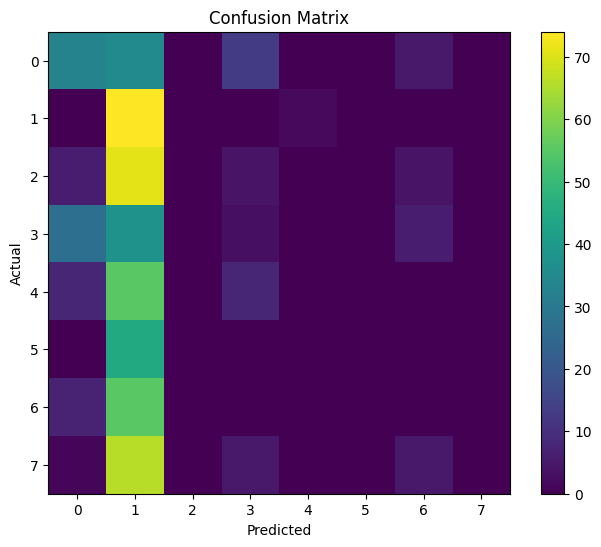

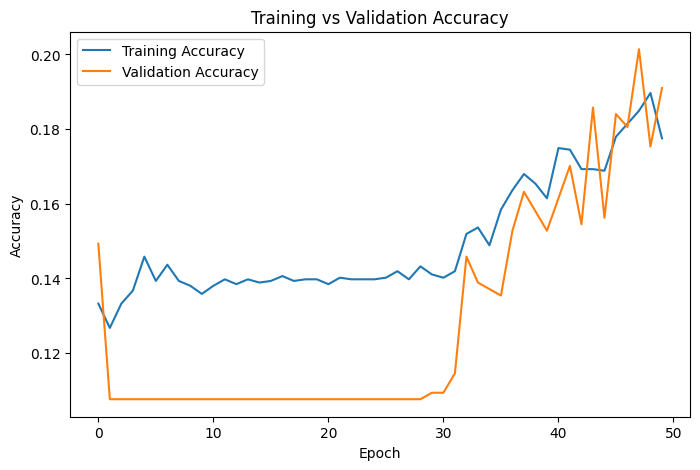

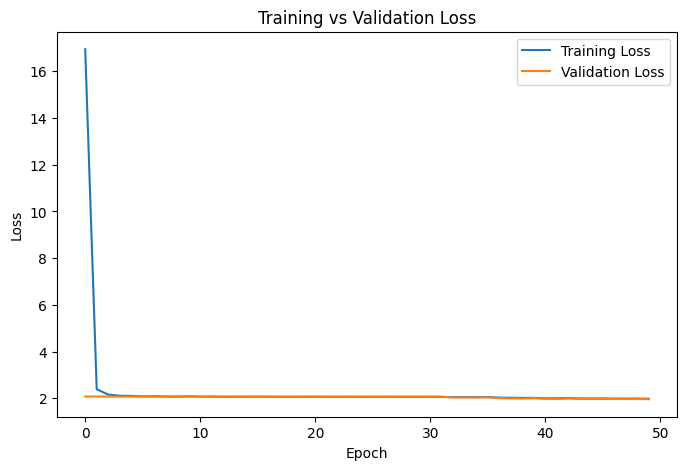


Model Saved Successfully!


In [7]:
# ============================================================
# EMOTION RECOGNITION FROM SPEECH USING DEEP LEARNING
# Dataset: RAVDESS
# ============================================================

# Install required library
!pip install librosa soundfile -q

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile # Import zipfile module

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================




# ============================================================
# DATASET PATH
# ============================================================

# Update this path if your zip file is in Google Drive
DATASET_ZIP_PATH = "/content/archive (3).zip" # Example: "/content/drive/MyDrive/archive (3).zip"
EXTRACT_DIR = "/content/RAVDESS_extracted" # Directory to extract files

# Create the extraction directory if it doesn't exist
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Update DATASET_PATH to the extracted directory
DATASET_PATH = EXTRACT_DIR

# ============================================================
# EMOTION LABELS
# ============================================================

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# ============================================================
# FEATURE EXTRACTION (MFCC)
# ============================================================

def extract_features(file_path):
    audio, sample_rate = librosa.load(
        file_path,
        duration=3,
        offset=0.5
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    return np.mean(mfcc.T, axis=0)

# ============================================================
# LOAD DATASET
# ============================================================

features = []
labels = []

print("Reading audio files...")

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.endswith(".wav"):

            try:

                emotion_code = file.split("-")[2]

                emotion = emotion_map.get(emotion_code)

                file_path = os.path.join(root, file)

                feature = extract_features(file_path)

                features.append(feature)
                labels.append(emotion)

            except:
                pass

print("Total Audio Files:", len(features))

# ============================================================
# PREPARE DATA
# ============================================================

X = np.array(features)

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

y = to_categorical(y)

print("Feature Shape:", X.shape)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================================
# BUILD MODEL
# ============================================================

model = Sequential()

model.add(Dense(
    256,
    activation='relu',
    input_shape=(40,)
))

model.add(Dropout(0.3))

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    y.shape[1],
    activation='softmax'
))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary:\n")
model.summary()

# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ============================================================
# EVALUATE MODEL
# ============================================================

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\n================================")
print("MODEL ACCURACY:", accuracy)
print("================================")

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_true_classes,
        y_pred_classes,
        target_names=encoder.classes_
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true_classes,
    y_pred_classes
)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

# ============================================================
# LOSS GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

# ============================================================
# SAVE MODEL
# ============================================================

model.save("emotion_recognition_model.h5")

print("\nModel Saved Successfully!")